In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(753)
m = 10_000
ns = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
tags = ["left", "mid", "right"]

In [2]:
def simulate_wiener(n, m):
    t = np.linspace(0, 1, n + 1)
    W = np.zeros((m, n + 1))
    W[:, 1:] = rng.normal(0, 1 / np.sqrt(n), size=(m, n))
    np.cumsum(W, axis=1, out=W)
    return t, W


def tagged_sums(n, m, batch_size=500):
    time_sums = np.empty((m, 3))
    wiener_sums = np.empty((m, 3))

    for start in range(0, m, batch_size):
        stop = min(start + batch_size, m)
        t, W = simulate_wiener(2 * n, stop - start)
        dW = W[:, 2::2] - W[:, :-2:2]
        tag_slices = [slice(0, -2, 2), slice(1, -1, 2), slice(2, None, 2)]

        for j, s in enumerate(tag_slices):
            time_sums[start:stop, j] = np.sum(t[s] * dW, axis=1)
            wiener_sums[start:stop, j] = np.sum(W[:, s] * dW, axis=1)

    return time_sums, wiener_sums


results = {n: tagged_sums(n, m) for n in ns}

Empirical mean: -0.00129 (theory: 0)
Empirical variance: 0.33719 (limit: 0.33333)


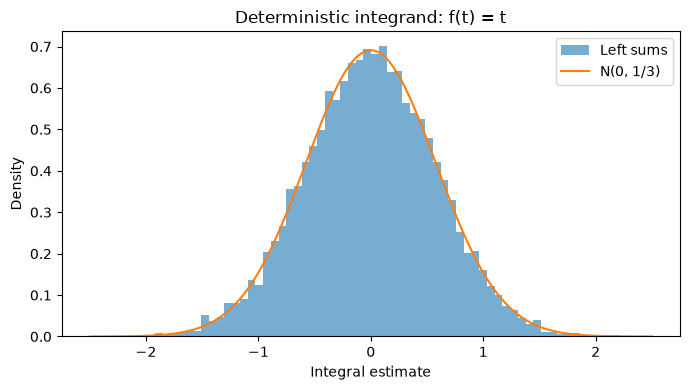

In [3]:
time_left = results[5000][0][:, 0]
print(f"Empirical mean: {time_left.mean():.5f} (theory: 0)")
print(f"Empirical variance: {time_left.var(ddof=1):.5f} (limit: {1/3:.5f})")

x = np.linspace(-2.5, 2.5, 400)
plt.figure(figsize=(7, 4))
plt.hist(time_left, bins=60, density=True, alpha=0.6, label="Left sums")
plt.plot(x, stats.norm.pdf(x, scale=np.sqrt(1 / 3)), label="N(0, 1/3)")
plt.xlabel("Integral estimate")
plt.ylabel("Density")
plt.title("Deterministic integrand: f(t) = t")
plt.legend()
plt.tight_layout()
plt.savefig("../written/figures/time_integral_output.png")
plt.show()

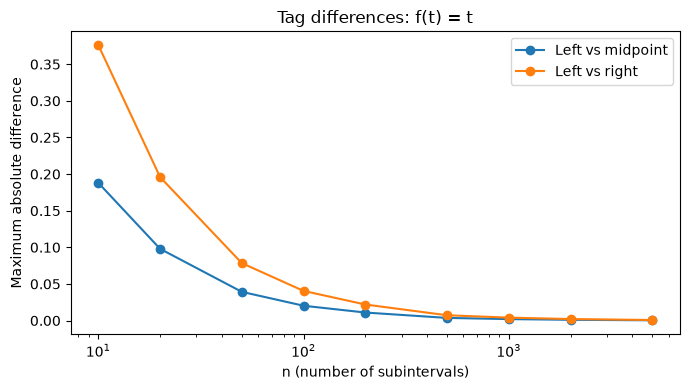

In [4]:
def plot_tag_differences(integrand, title, filename):
    differences = np.array([
        np.max(np.abs(results[n][integrand][:, 1:]
                      - results[n][integrand][:, :1]), axis=0)
        for n in ns
    ])
    plt.figure(figsize=(7, 4))
    plt.plot(ns, differences[:, 0], "o-", label="Left vs midpoint")
    plt.plot(ns, differences[:, 1], "o-", label="Left vs right")
    plt.xscale("log")
    plt.xlabel("n (number of subintervals)")
    plt.ylabel("Maximum absolute difference")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../written/figures/{filename}")
    plt.show()


plot_tag_differences(0, "Tag differences: f(t) = t", "time_tag_differences_output.png")

Empirical mean: 0.00005 (theory: 0)
Empirical variance: 0.48718 (limit: 0.50000)


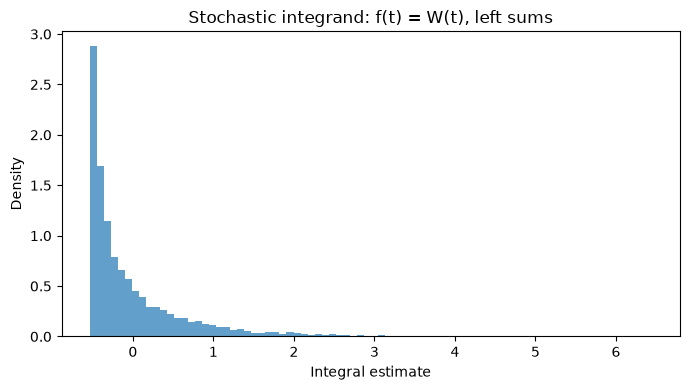

In [5]:
wiener_left = results[5000][1][:, 0]
print(f"Empirical mean: {wiener_left.mean():.5f} (theory: 0)")
print(f"Empirical variance: {wiener_left.var(ddof=1):.5f} (limit: 0.50000)")

plt.figure(figsize=(7, 4))
plt.hist(wiener_left, bins=80, density=True, alpha=0.7)
plt.xlabel("Integral estimate")
plt.ylabel("Density")
plt.title("Stochastic integrand: f(t) = W(t), left sums")
plt.tight_layout()
plt.savefig("../written/figures/wiener_integral_output.png")
plt.show()

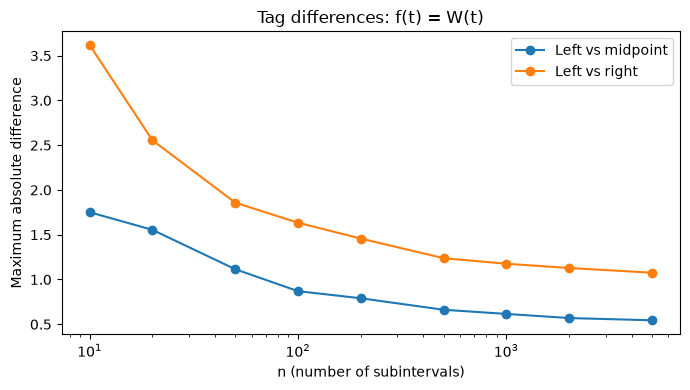

In [6]:
plot_tag_differences(1, "Tag differences: f(t) = W(t)", "wiener_tag_differences_output.png")